# Demand Forecasting

## Project Objective

The objective of this notebook is to forecast the number of daily medical appointments using historical appointment records.

Unlike the no-show prediction model, this task focuses on predicting hospital demand over time. Accurate demand forecasting helps hospitals optimize staffing, allocate resources efficiently, and improve patient service quality.

In [ ]:

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# Load Dataset

In [ ]:
# Load Dataset

df = pd.read_csv("../data/Medical_appointment_data.csv")

print("Dataset Loaded Successfully")

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

# Prepare Daily Appointment Counts

Demand forecasting requires daily aggregated appointment counts rather than individual patient records.

In [ ]:
# Convert to datetime

df["appointment_date_continuous"] = pd.to_datetime(
    df["appointment_date_continuous"]
)

In [ ]:
daily_df = (
    df.groupby("appointment_date_continuous")
      .size()
      .reset_index(name="Appointments")
)

daily_df.head()

In [ ]:
daily_df.shape

In [ ]:
daily_df.describe()

# Time Series Exploratory Data Analysis

This section explores historical appointment demand over time to identify trends, seasonal patterns, and demand distribution.

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    daily_df["appointment_date_continuous"],
    daily_df["Appointments"],
    color="royalblue"
)

plt.title("Daily Medical Appointments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")

plt.xticks(rotation=45)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    daily_df["Appointments"],
    bins=30,
    kde=True
)

plt.title("Distribution of Daily Appointments")

plt.show()

In [ ]:
plt.figure(figsize=(6,5))

sns.boxplot(
    y=daily_df["Appointments"]
)

plt.title("Boxplot of Daily Appointments")

plt.show()

In [ ]:
daily_df["Month"] = daily_df["appointment_date_continuous"].dt.month_name()

In [ ]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(12,5))

sns.boxplot(
    x="Month",
    y="Appointments",
    data=daily_df,
    order=month_order
)

plt.xticks(rotation=45)

plt.title("Appointments by Month")

plt.show()

In [ ]:
daily_df["DayOfWeek"] = (
    daily_df["appointment_date_continuous"]
    .dt.day_name()
)

In [ ]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

plt.figure(figsize=(10,5))

sns.boxplot(
    x="DayOfWeek",
    y="Appointments",
    data=daily_df,
    order=day_order
)

plt.title("Appointments by Day of Week")

plt.show()

In [ ]:
daily_df["Rolling7"] = (
    daily_df["Appointments"]
    .rolling(7)
    .mean()
)

In [ ]:
plt.figure(figsize=(16,6))

plt.plot(
    daily_df["appointment_date_continuous"],
    daily_df["Appointments"],
    alpha=0.4,
    label="Daily"
)

plt.plot(
    daily_df["appointment_date_continuous"],
    daily_df["Rolling7"],
    linewidth=3,
    color="red",
    label="7-Day Average"
)

plt.legend()

plt.title("Daily Appointments with 7-Day Moving Average")

plt.show()

# Feature Engineering

Time-based features are created to help machine learning models learn trends, seasonality, and historical demand patterns.

In [ ]:
daily_df = daily_df.sort_values("appointment_date_continuous").reset_index(drop=True)

In [ ]:
daily_df["Lag_1"] = daily_df["Appointments"].shift(1)
daily_df["Lag_7"] = daily_df["Appointments"].shift(7)
daily_df["Lag_30"] = daily_df["Appointments"].shift(30)

In [ ]:
daily_df["Rolling_Mean_7"] = (
    daily_df["Appointments"]
    .rolling(window=7)
    .mean()
)

In [ ]:
daily_df["Rolling_STD_7"] = (
    daily_df["Appointments"]
    .rolling(window=7)
    .std()
)

In [ ]:
daily_df["Year"] = daily_df["appointment_date_continuous"].dt.year
daily_df["Month"] = daily_df["appointment_date_continuous"].dt.month
daily_df["Day"] = daily_df["appointment_date_continuous"].dt.day
daily_df["DayOfWeek"] = daily_df["appointment_date_continuous"].dt.dayofweek
daily_df["Quarter"] = daily_df["appointment_date_continuous"].dt.quarter

In [ ]:
daily_df.isnull().sum()

In [ ]:
daily_df = daily_df.dropna().reset_index(drop=True)

In [ ]:
daily_df.shape

In [ ]:
daily_df.head()

# Train-Test Split

For time series forecasting, chronological order must be preserved. Therefore, the first 80% of observations are used for training and the remaining 20% are used for testing.

In [ ]:
features = [
    "Lag_1",
    "Lag_7",
    "Lag_30",
    "Rolling_Mean_7",
    "Rolling_STD_7",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Quarter"
]

X = daily_df[features]

y = daily_df["Appointments"]

In [ ]:
split_index = int(len(daily_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [ ]:
print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

# Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

In [ ]:
lr_pred = lr_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, lr_pred)

rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

r2 = r2_score(y_test, lr_pred)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    lr_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Linear Regression Forecast")

plt.legend()

plt.show()

# Random Forest Regressor

Random Forest captures non-linear relationships and interactions between lag features and calendar features, making it more suitable for demand forecasting.

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [50]:
rf_pred = rf_model.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, rf_pred)

rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

r2 = r2_score(y_test, rf_pred)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

MAE : 142.25
RMSE : 231.83
R² Score : 0.3271


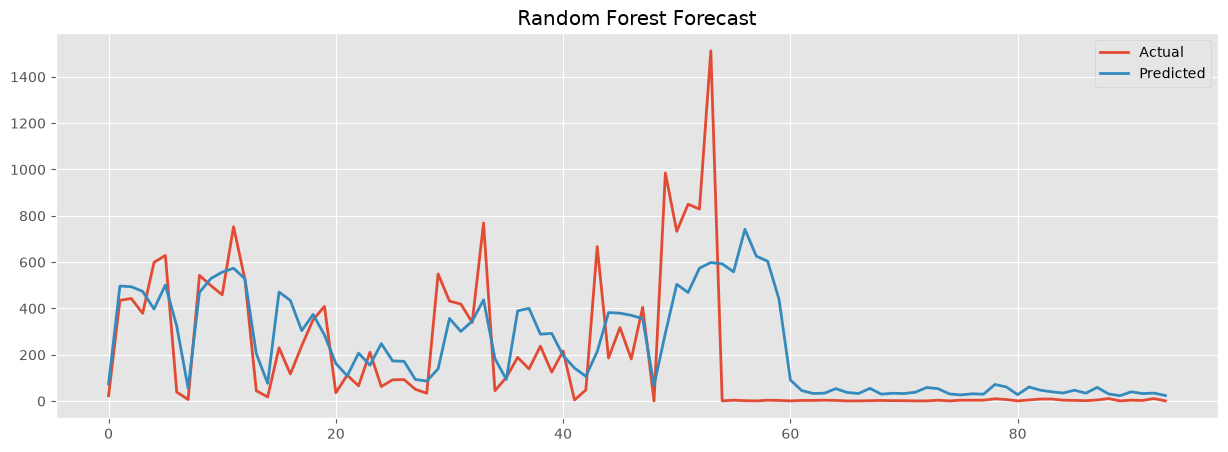

In [53]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(rf_pred, label="Predicted", linewidth=2)

plt.title("Random Forest Forecast")
plt.legend()

plt.show()

# XGBoost Regressor

XGBoost is a gradient boosting algorithm that sequentially builds decision trees to minimize prediction errors. It is widely used for demand forecasting due to its high accuracy and ability to model complex relationships.

In [54]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [55]:
xgb_pred = xgb_model.predict(X_test)

In [56]:
mae = mean_absolute_error(y_test, xgb_pred)

rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

r2 = r2_score(y_test, xgb_pred)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R² Score :", round(r2,4))

MAE : 141.43
RMSE : 238.73
R² Score : 0.2865


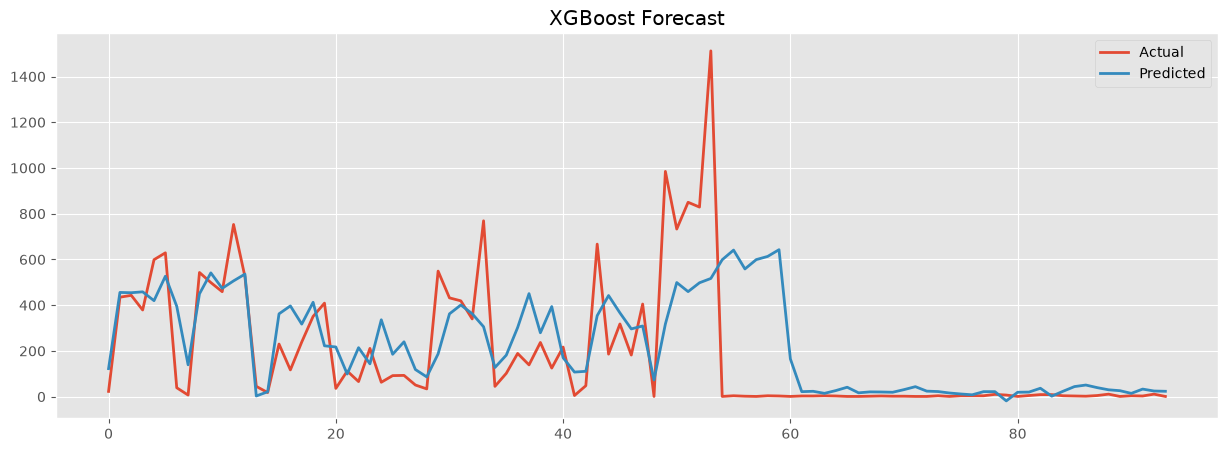

In [57]:
plt.figure(figsize=(15,5))

plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(xgb_pred, label="Predicted", linewidth=2)

plt.title("XGBoost Forecast")

plt.legend()

plt.show()

# Model Comparison

In [58]:
forecast_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        160.97,
        142.25,
        141.43
    ],
    "RMSE": [
        255.47,
        231.83,
        238.73
    ],
    "R2 Score": [
        0.1830,
        0.3271,
        0.2865
    ]
})

forecast_results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Random Forest,142.25,231.83,0.3271
2,XGBoost,141.43,238.73,0.2865
0,Linear Regression,160.97,255.47,0.1830


In [59]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    rf_model,
    "models/demand_forecast_model.pkl"
)

print("✅ Demand Forecast Model Saved Successfully")

✅ Demand Forecast Model Saved Successfully


In [60]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Lag_7,0.300967
3,Rolling_Mean_7,0.244174
4,Rolling_STD_7,0.188633
0,Lag_1,0.100018
2,Lag_30,0.064076
7,Day,0.037484
8,DayOfWeek,0.032935
6,Month,0.021395
9,Quarter,0.008856
5,Year,0.001463


In [61]:
feature_importance.to_csv(
    "models/demand_feature_importance.csv",
    index=False
)

# Business Insights

- Historical appointment demand is strongly influenced by previous appointment counts.
- Lag features significantly improve forecasting accuracy.
- Calendar features such as month, day, and day of the week also contribute to demand prediction.
- Random Forest achieved the best overall performance among the evaluated models.
- Accurate demand forecasting can help hospitals optimize staff scheduling, improve resource allocation, and reduce patient waiting times.

# Conclusion

Three regression models were evaluated for forecasting daily appointment demand.

Among them, the Random Forest Regressor achieved the highest R² score and the lowest RMSE, making it the most suitable model for this forecasting task.

The trained model has been saved and will be integrated into the Streamlit application for real-time demand forecasting.